<a href="https://colab.research.google.com/github/tejasabert/NHANES_FTI/blob/main/TejasAbert_NHANESFTI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

How do height and weight each vary across the adult lifespan, and to what extent does age-related height loss distort BMI as a measure of body composition in older adults?



In [8]:
import pandas as pd
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Health%20and%20Nutrition%20(NHANES)/health_and_nutrition_combined_clean.csv"
df = pd.read_csv(url)
df.head(40)

,Unnamed: 0,SEQN,RIAGENDR,RIDRETH3,RIDAGEYR,BMXHT,BMXBMI,BMXWT,RIDEXPRG,WTMEC4YR
0,0,83732,1,3,62,1845.0,27.8,94.8,NaN,NaN
1,1,83733,1,3,53,1714.0,30.8,90.4,NaN,NaN
2,2,83734,1,3,78,1701.0,28.8,83.4,NaN,NaN
3,3,83741,1,4,22,1654.0,28.0,76.6,NaN,NaN
4,4,83744,1,4,56,1794.0,33.6,108.3,NaN,NaN
5,5,83747,1,3,46,1767.0,27.6,86.2,NaN,NaN
6,6,83750,1,7,45,1778.0,24.1,76.2,NaN,NaN
7,7,83755,1,4,67,1838.0,28.8,97.4,NaN,NaN
8,8,83769,1,6,49,1707.0,25.0,72.8,NaN,NaN
9,9,83777,1,6,56,1661.0,25.0,69.0,NaN,NaN


In [9]:
df = pd.read_csv(url)

# drop rows missing BMI height or weight
df = df.dropna(subset=['BMXBMI', 'BMXHT', 'BMXWT'])

# remove pregnant participants
df = df[df['RIDEXPRG'] != 1]

# convert height from mm to cm
df['BMXHT'] = df['BMXHT'] / 10

# rename the columns
df = df.rename(columns={
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Sex',
    'RIDRETH3': 'Race',
    'BMXHT': 'Height_cm',
    'BMXWT': 'Weight_kg',
    'BMXBMI': 'BMI'
})

# turn numbers into labels
df['Sex'] = df['Sex'].map({1: 'Male', 2: 'Female'})
df['Race'] = df['Race'].map({
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other/Multi'
})

#checking
print(f"Rows left: {len(df)}")
print(df.head())


Rows left: 10457
   Unnamed: 0   SEQN   Sex                Race  Age  Height_cm   BMI  \
0           0  83732  Male  Non-Hispanic White   62      184.5  27.8   
1           1  83733  Male  Non-Hispanic White   53      171.4  30.8   
2           2  83734  Male  Non-Hispanic White   78      170.1  28.8   
3           3  83741  Male  Non-Hispanic Black   22      165.4  28.0   
4           4  83744  Male  Non-Hispanic Black   56      179.4  33.6   

   Weight_kg  RIDEXPRG  WTMEC4YR  
0       94.8       NaN       NaN  
1       90.4       NaN       NaN  
2       83.4       NaN       NaN  
3       76.6       NaN       NaN  
4      108.3       NaN       NaN  


In [10]:
#remove unneeded colunmn
df = df.drop(columns=['Unnamed: 0'])

In [11]:
#drop this becuase its NaNs
df = df.drop(columns=['WTMEC4YR'])

In [12]:
print(len(df))

10457


In [13]:
# drop pregnant
df = df.drop(columns=['RIDEXPRG'])
#check for remaining NaNs
print(df.isna().sum())

SEQN         0
Sex          0
Race         0
Age          0
Height_cm    0
BMI          0
Weight_kg    0
dtype: int64


In [14]:
#cleaned version
df.to_csv("health_cleaned.csv", index=False)
df.head(10)

,SEQN,Sex,Race,Age,Height_cm,BMI,Weight_kg
0,83732,Male,Non-Hispanic White,62,184.5,27.8,94.8
1,83733,Male,Non-Hispanic White,53,171.4,30.8,90.4
2,83734,Male,Non-Hispanic White,78,170.1,28.8,83.4
3,83741,Male,Non-Hispanic Black,22,165.4,28.0,76.6
4,83744,Male,Non-Hispanic Black,56,179.4,33.6,108.3
5,83747,Male,Non-Hispanic White,46,176.7,27.6,86.2
6,83750,Male,Other/Multi,45,177.8,24.1,76.2
7,83755,Male,Non-Hispanic Black,67,183.8,28.8,97.4
8,83769,Male,Non-Hispanic Asian,49,170.7,25.0,72.8
9,83777,Male,Non-Hispanic Asian,56,166.1,25.0,69.0


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10457 entries, 0 to 10613
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       10457 non-null  int64  
 1   Sex        10457 non-null  object 
 2   Race       10457 non-null  object 
 3   Age        10457 non-null  int64  
 4   Height_cm  10457 non-null  float64
 5   BMI        10457 non-null  float64
 6   Weight_kg  10457 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 653.6+ KB


In [16]:
df.groupby('Age')[['BMI','Weight_kg','Height_cm']].mean()

,BMI,Weight_kg,Height_cm
Age,,,
20,26.637931,76.080000,168.616552
21,28.782051,80.617949,167.183761
22,27.799429,79.321714,168.682286
23,26.955758,75.951515,167.909091
24,28.147500,78.966875,167.554375
...,...,...,...
76,29.362069,81.421839,166.595402
77,29.920690,81.482759,164.342529
78,29.005952,78.305952,163.972619


/tmp/ipykernel_889/2946089062.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(men.groupby('AgeGroup')['BMI'].mean().index, men.groupby('AgeGroup')['BMI'].mean().values, marker='o', color='blue', label='Male')
/tmp/ipykernel_889/2946089062.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(women.groupby('AgeGroup')['BMI'].mean().index, women.groupby('AgeGroup')['BMI'].mean().values, marker='o', color='red', label='Female')


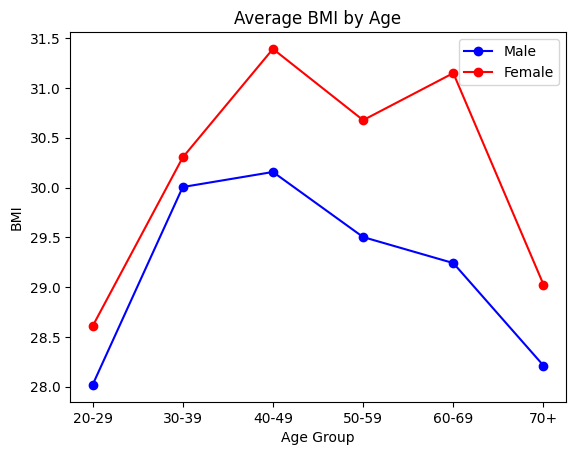

/tmp/ipykernel_889/2946089062.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(men.groupby('AgeGroup')['Weight_kg'].mean().index, men.groupby('AgeGroup')['Weight_kg'].mean().values, marker='o', color='blue', label='Male')
/tmp/ipykernel_889/2946089062.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(women.groupby('AgeGroup')['Weight_kg'].mean().index, women.groupby('AgeGroup')['Weight_kg'].mean().values, marker='o', color='red', label='Female')


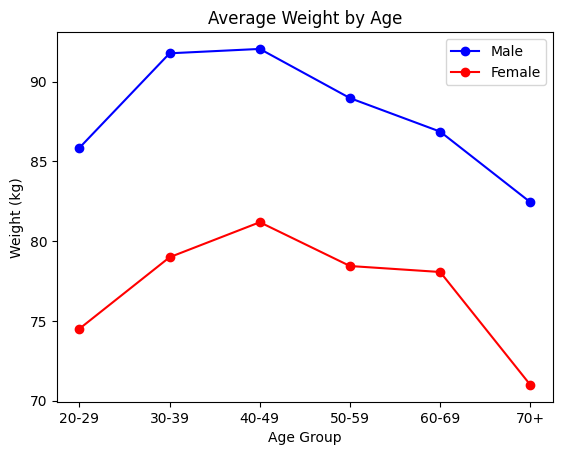

/tmp/ipykernel_889/2946089062.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(men.groupby('AgeGroup')['Height_cm'].mean().index, men.groupby('AgeGroup')['Height_cm'].mean().values, marker='o', color='blue', label='Male')
/tmp/ipykernel_889/2946089062.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plt.plot(women.groupby('AgeGroup')['Height_cm'].mean().index, women.groupby('AgeGroup')['Height_cm'].mean().values, marker='o', color='red', label='Female')


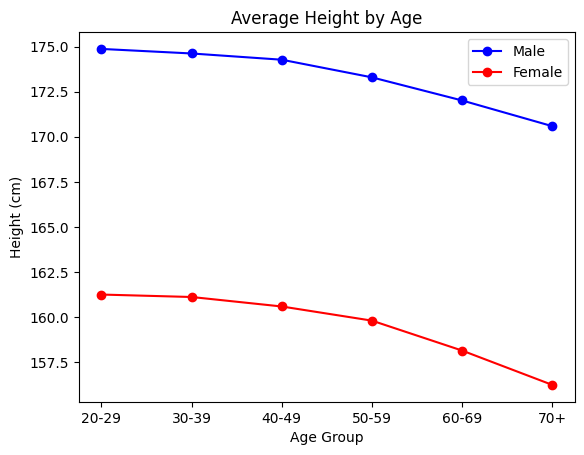

In [17]:
import matplotlib.pyplot as plt

# age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,81],
                        labels=['20-29','30-39','40-49','50-59','60-69','70+'])

# split into men and women
men = df[df['Sex']=='Male']
women = df[df['Sex']=='Female']

# chart 1 (BMI)
plt.plot(men.groupby('AgeGroup')['BMI'].mean().index, men.groupby('AgeGroup')['BMI'].mean().values, marker='o', color='blue', label='Male')
plt.plot(women.groupby('AgeGroup')['BMI'].mean().index, women.groupby('AgeGroup')['BMI'].mean().values, marker='o', color='red', label='Female')
plt.title('Average BMI by Age')
plt.xlabel('Age Group')
plt.ylabel('BMI')
plt.legend()
plt.show()

# chart 2 (Weight)
plt.plot(men.groupby('AgeGroup')['Weight_kg'].mean().index, men.groupby('AgeGroup')['Weight_kg'].mean().values, marker='o', color='blue', label='Male')
plt.plot(women.groupby('AgeGroup')['Weight_kg'].mean().index, women.groupby('AgeGroup')['Weight_kg'].mean().values, marker='o', color='red', label='Female')
plt.title('Average Weight by Age')
plt.xlabel('Age Group')
plt.ylabel('Weight (kg)')
plt.legend()
plt.show()

# chart 3 (Height)
plt.plot(men.groupby('AgeGroup')['Height_cm'].mean().index, men.groupby('AgeGroup')['Height_cm'].mean().values, marker='o', color='blue', label='Male')
plt.plot(women.groupby('AgeGroup')['Height_cm'].mean().index, women.groupby('AgeGroup')['Height_cm'].mean().values, marker='o', color='red', label='Female')
plt.title('Average Height by Age')
plt.xlabel('Age Group')
plt.ylabel('Height (cm)')
plt.legend()
plt.show()

/tmp/ipykernel_889/490326202.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  actual = df.groupby('AgeGroup')['BMI'].mean()
/tmp/ipykernel_889/490326202.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corrected = df.groupby('AgeGroup')['BMI_corrected'].mean()


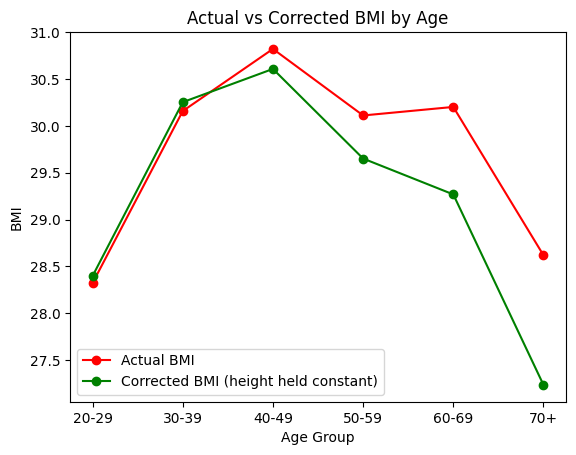

In [18]:
#young adults average height
baseline_height = df[df['AgeGroup']=='20-29']['Height_cm'].mean()

# corrected BMI = same weight but constant height
df['BMI_corrected'] = df['Weight_kg'] / ((baseline_height/100) ** 2)

# average both by age group
actual = df.groupby('AgeGroup')['BMI'].mean()
corrected = df.groupby('AgeGroup')['BMI_corrected'].mean()

plt.plot(actual.index, actual.values, marker='o', color='red', label='Actual BMI')
plt.plot(corrected.index, corrected.values, marker='o', color='green', label='Corrected BMI (height held constant)')
plt.title('Actual vs Corrected BMI by Age')
plt.xlabel('Age Group')
plt.ylabel('BMI')
plt.legend()
plt.show()

In [19]:
print(df.isna().sum())

SEQN               0
Sex                0
Race               0
Age                0
Height_cm          0
BMI                0
Weight_kg          0
AgeGroup         145
BMI_corrected      0
dtype: int64


In [20]:
print(df[df['AgeGroup'].isna()]['Age'].describe())

count    145.0
mean      20.0
std        0.0
min       20.0
25%       20.0
50%       20.0
75%       20.0
max       20.0
Name: Age, dtype: float64


In [21]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50,60,70,81], labels=['20-29','30-39','40-49','50-59','60-69','70+'], include_lowest=True)

In [22]:
print(df['AgeGroup'].isna().sum())

0


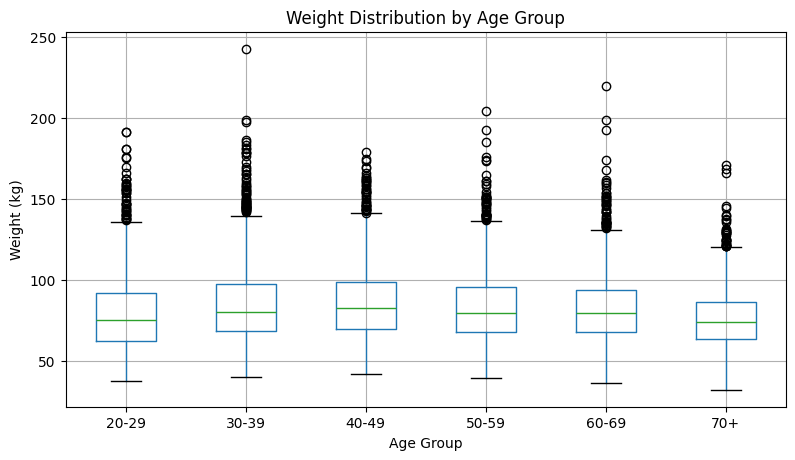

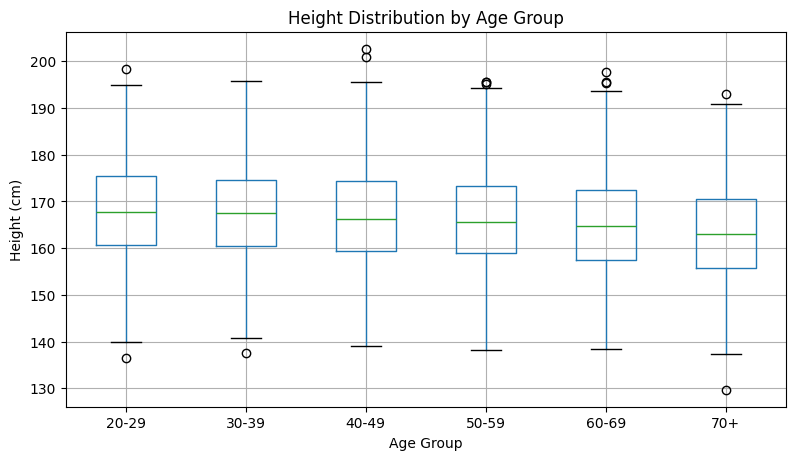

In [23]:
import matplotlib.pyplot as plt

# box plot of WEIGHT by age group
df.boxplot(column='Weight_kg', by='AgeGroup', figsize=(9,5))
plt.title('Weight Distribution by Age Group')
plt.suptitle('')   # removes the automatic pandas title
plt.xlabel('Age Group')
plt.ylabel('Weight (kg)')
plt.show()

# box plot of HEIGHT by age group
df.boxplot(column='Height_cm', by='AgeGroup', figsize=(9,5))
plt.title('Height Distribution by Age Group')
plt.suptitle('')
plt.xlabel('Age Group')
plt.ylabel('Height (cm)')
plt.show()

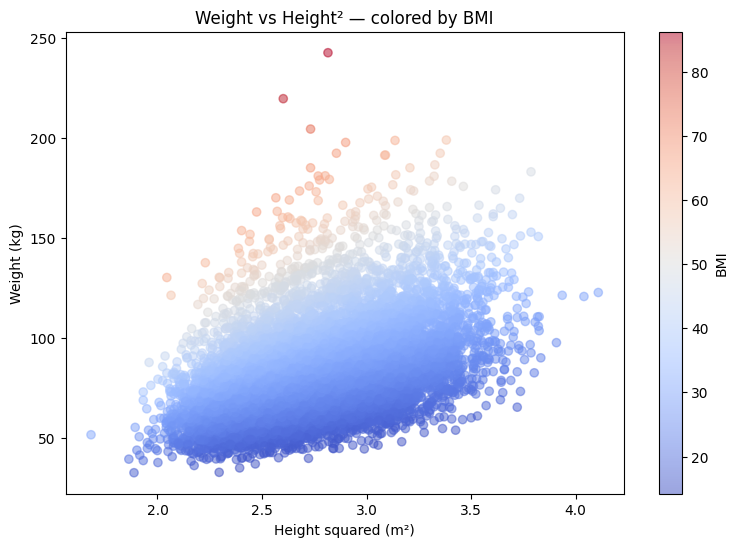

In [24]:
import matplotlib.pyplot as plt

# height squared (in meters) for the x-axis
height_m = df['Height_cm'] / 100
df['Height_sq'] = height_m ** 2

# scatter: x = height squared, y = weight, color = BMI
plt.figure(figsize=(9,6))
scatter = plt.scatter(df['Height_sq'], df['Weight_kg'],
                      c=df['BMI'], cmap='coolwarm', alpha=0.5)
plt.colorbar(scatter, label='BMI')
plt.xlabel('Height squared (m²)')
plt.ylabel('Weight (kg)')
plt.title('Weight vs Height² — colored by BMI')
plt.show()

/tmp/ipykernel_889/1086938540.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


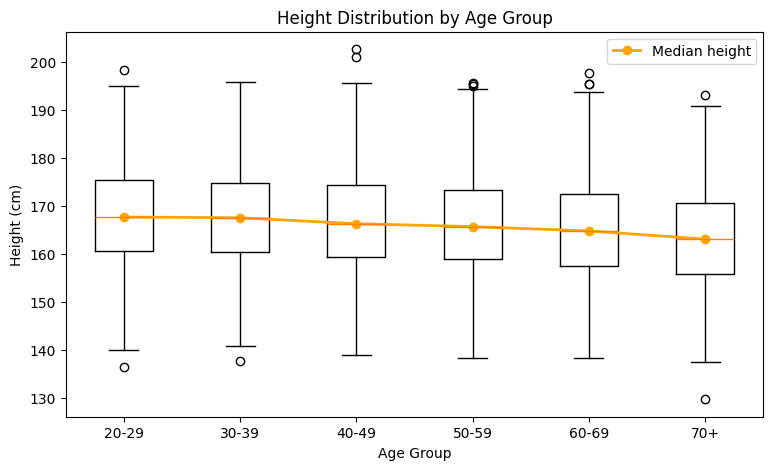

In [25]:
import matplotlib.pyplot as plt

# get the data for each group into a list
groups = ['20-29','30-39','40-49','50-59','60-69','70+']
data = [df[df['AgeGroup']==g]['Height_cm'].dropna() for g in groups]

# box plot
plt.figure(figsize=(9,5))
plt.boxplot(data, labels=groups)

# median line on top
medians = [d.median() for d in data]
plt.plot(range(1, len(groups)+1), medians, color='orange', marker='o', linewidth=2, label='Median height')

plt.title('Height Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Height (cm)')
plt.legend()
plt.show()

/tmp/ipykernel_889/3856445576.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=groups, patch_artist=True)


Text(0.5, 1.0, 'Weight Distribution by Age Group')

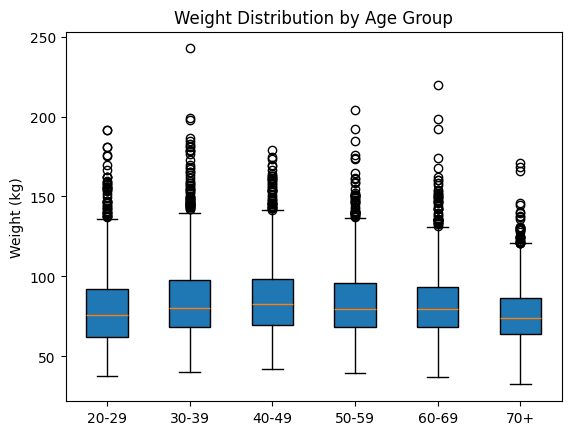

In [26]:
data = [df[df['AgeGroup']==g]['Weight_kg'].dropna() for g in groups]
box = plt.boxplot(data, labels=groups, patch_artist=True)
# ...same styling...
plt.ylabel('Weight (kg)')
plt.title('Weight Distribution by Age Group')

/tmp/ipykernel_889/1432908163.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=groups, patch_artist=True)


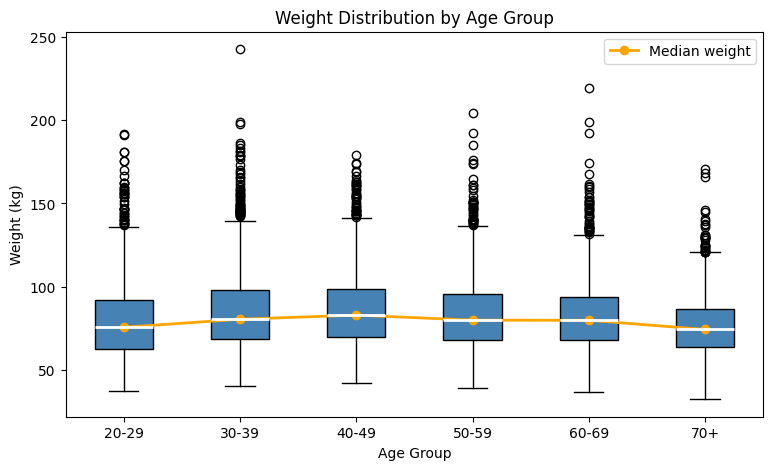

In [27]:
import matplotlib.pyplot as plt

# get weight data for each group
groups = ['20-29','30-39','40-49','50-59','60-69','70+']
data = [df[df['AgeGroup']==g]['Weight_kg'].dropna() for g in groups]

# box plot with filled boxes
plt.figure(figsize=(9,5))
box = plt.boxplot(data, labels=groups, patch_artist=True)

# fill the boxes
for patch in box['boxes']:
    patch.set_facecolor('steelblue')

# white median lines so they show against the fill
for median in box['medians']:
    median.set_color('white')
    median.set_linewidth(2)

# median trend line on top
medians = [d.median() for d in data]
plt.plot(range(1, len(groups)+1), medians, color='orange', marker='o', linewidth=2, label='Median weight')

plt.title('Weight Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Weight (kg)')
plt.legend()
plt.show()

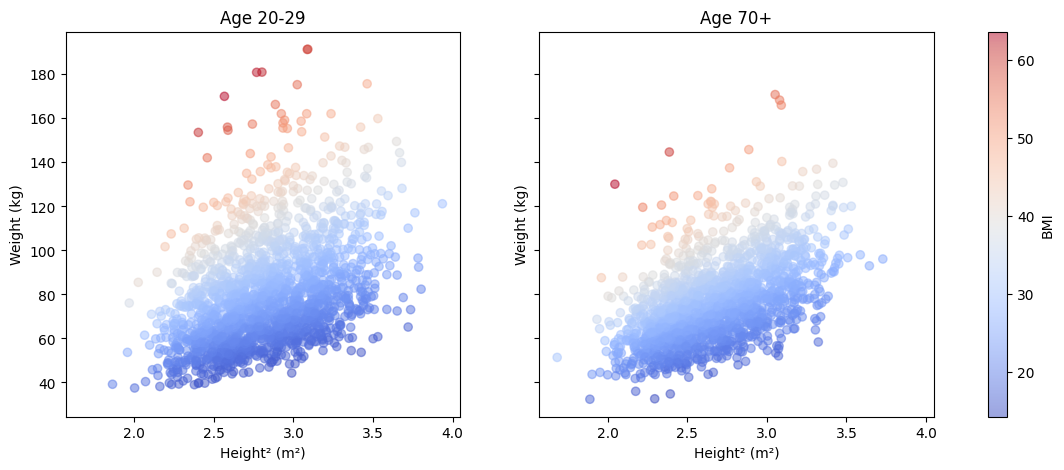

In [28]:
import matplotlib.pyplot as plt

young = df[df['AgeGroup']=='20-29']
old = df[df['AgeGroup']=='70+']

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharex=True, sharey=True)

for ax, subset, title in zip(axes, [young, old], ['Age 20-29', 'Age 70+']):
    sc = ax.scatter(subset['Height_sq'], subset['Weight_kg'],
                    c=subset['BMI'], cmap='coolwarm', alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('Height² (m²)')
    ax.set_ylabel('Weight (kg)')

fig.colorbar(sc, ax=axes, label='BMI')
plt.show()

/tmp/ipykernel_889/1971008110.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=groups, patch_artist=True)


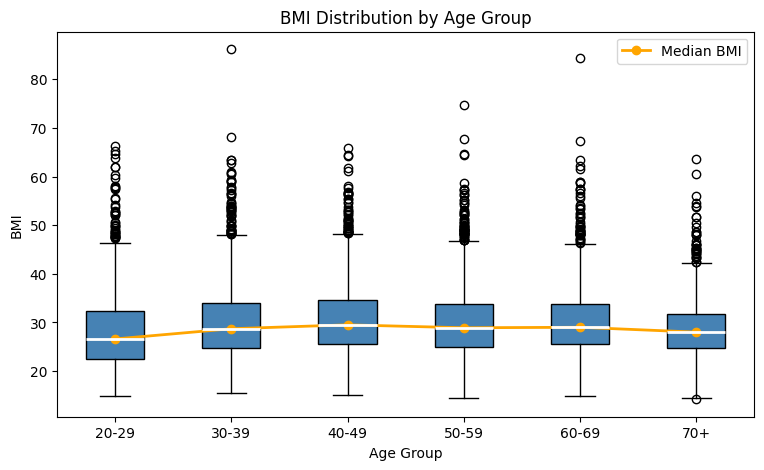

In [29]:
import matplotlib.pyplot as plt

# get the BMI data for each group
groups = ['20-29','30-39','40-49','50-59','60-69','70+']
data = [df[df['AgeGroup']==g]['BMI'].dropna() for g in groups]

# box plot with filled boxes
plt.figure(figsize=(9,5))
box = plt.boxplot(data, labels=groups, patch_artist=True)

# fill each box
for patch in box['boxes']:
    patch.set_facecolor('steelblue')

# white median lines so they show against the fill
for median in box['medians']:
    median.set_color('white')
    median.set_linewidth(2)

# median trend line on top
medians = [d.median() for d in data]
plt.plot(range(1, len(groups)+1), medians, color='orange', marker='o', linewidth=2, label='Median BMI')

plt.title('BMI Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('BMI')
plt.legend()
plt.show()

In [30]:
print(df.groupby('AgeGroup')['BMI'].median())
print(df.groupby('AgeGroup')['BMI'].mean())

AgeGroup
20-29    26.6
30-39    28.7
40-49    29.5
50-59    28.9
60-69    29.0
70+      28.0
Name: BMI, dtype: float64
AgeGroup
20-29    28.186265
30-39    30.157844
40-49    30.820793
50-59    30.110774
60-69    30.201787
70+      28.619231
Name: BMI, dtype: float64


/tmp/ipykernel_889/3029758555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['BMI'].median())
/tmp/ipykernel_889/3029758555.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AgeGroup')['BMI'].mean())


In [31]:
# median BMI, weight, height for the peak group (40s) and oldest group
for g in ['40-49', '70+']:
    sub = df[df['AgeGroup']==g]
    print(g, "BMI:", round(sub['BMI'].median(),1),
             "Weight:", round(sub['Weight_kg'].median(),1),
             "Height:", round(sub['Height_cm'].median(),1))

40-49 BMI: 29.5 Weight: 82.9 Height: 166.3
70+ BMI: 28.0 Weight: 74.3 Height: 163.1


In [32]:
from scipy import stats

group_40s = df[df['AgeGroup']=='40-49']['BMI'].dropna()
group_70s = df[df['AgeGroup']=='70+']['BMI'].dropna()

t_stat, p_value = stats.ttest_ind(group_40s, group_70s)

print("40-49 mean BMI:", round(group_40s.mean(), 2))
print("70+ mean BMI:", round(group_70s.mean(), 2))
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_value)

40-49 mean BMI: 30.82
70+ mean BMI: 28.62
t-statistic: 9.466
p-value: 5.3657775641717176e-21


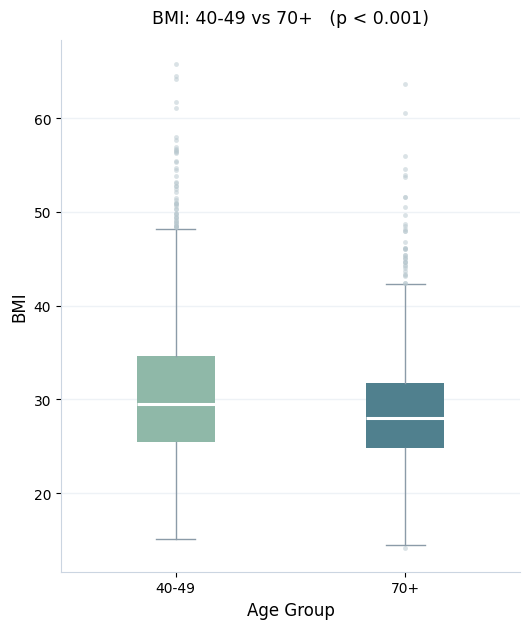

In [42]:
import matplotlib.pyplot as plt

groups = ['40-49', '70+']
data = [df[df['AgeGroup']==g]['BMI'].dropna() for g in groups]

fig, ax = plt.subplots(figsize=(5.4, 6.4))

box = ax.boxplot(data, tick_labels=groups, patch_artist=True, widths=0.34)


colors = ['#8FB8A8', '#50808E']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('none')


for median in box['medians']:
    median.set_color('white')
    median.set_linewidth(2.2)


for whisker in box['whiskers']:
    whisker.set_color('#8B9BA8')
for cap in box['caps']:
    cap.set_color('#8B9BA8')


for flier in box['fliers']:
    flier.set_marker('o')
    flier.set_markersize(3.5)
    flier.set_markerfacecolor('#B7C7CE')
    flier.set_markeredgecolor('none')
    flier.set_alpha(0.5)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.grid(axis='y', color='#EEF2F6', linewidth=1)
ax.set_axisbelow(True)


ax.set_title('BMI: 40-49 vs 70+   (p < 0.001)', fontsize=12.5, pad=12)
ax.set_ylabel('BMI', fontsize=12)
ax.set_xlabel('Age Group', fontsize=12)

plt.tight_layout()
plt.show()

In [34]:
from scipy import stats
#ANOVA
groups = ['20-29','30-39','40-49','50-59','60-69','70+']
bmi_by_group = [df[df['AgeGroup']==g]['BMI'].dropna() for g in groups]

f_stat, p_value = stats.f_oneway(*bmi_by_group)

print("F-statistic:", round(f_stat, 3))
print("p-value:", p_value)

F-statistic: 35.792
p-value: 1.8562807686181582e-36


In [35]:
height_by_group = [df[df['AgeGroup']==g]['Height_cm'].dropna() for g in groups]
f_stat, p_value = stats.f_oneway(*height_by_group)
#ANOVA for heights
print("Height F-statistic:", round(f_stat, 3))
print("Height p-value:", p_value)

Height F-statistic: 49.82
Height p-value: 3.572721961268113e-51
